El valor de beta es 2.6622780026990555e-20


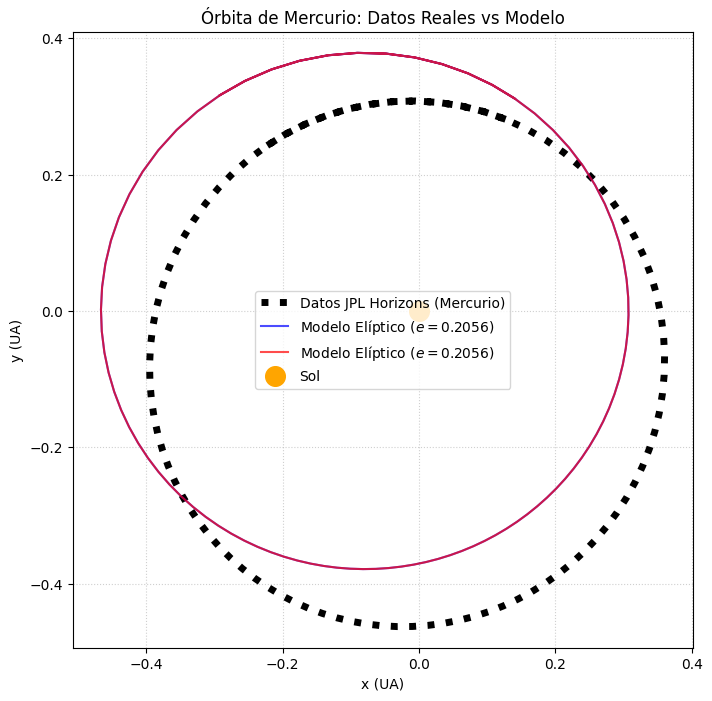

In [ ]:
!pip install astroquery
import numpy as np
import matplotlib.pyplot as plt
from astroquery.jplhorizons import Horizons

#------Constantes
c = 3*10**8
G_M_SUN = 0.0002959122

# 1. Parámetros de la consulta a JPL Horizons
# ID de Mercurio: 199 (Júpiter es 599)
# Centro: @sun (coordenadas heliocéntricas)

# Rango de tiempo: Un año de Mercurio es ~88 días, pedimos 100 para ver la órbita completa
obj = Horizons(id='199', location='@sun',
               epochs={'start': '2023-01-01', 'stop': '2023-04-10', 'step': '1d'})

# Obtener los vectores de estado (x, y, z)
vectors = obj.vectors()

# Extraer coordenadas en Unidades Astronómicas (AU)
x_mercurio = ####
y_mercurio = ####

# 2. Estimación de parámetros para el modelo teórico
# Para Mercurio: a ≈ 0.387 AU, e ≈ 0.2056
e_estimado = 0.2056
p_estimado = 0.3705

#Calculando valor del parámetro beta
betareal = (3*G_M_SUN)/(p_estimado*c**2)
betafalso= 4/100
print(f"El valor de beta es {betareal}")

# Crear el modelo teórico
phi = np.arctan2(####, ####)

#Modelo de Newton
r_teorico = ####
x_teorico = r_teorico * np.cos(phi)
y_teorico = r_teorico * np.sin(phi)

#Modelo de Einstein
u_einstein = (1+e_estimado*np.cos(phi))/p_estimado + betareal*(1+(e_estimado**2)/2 + e_estimado*phi*np.sin(phi)- np.cos(2*phi)*(e_estimado**2)/6)/p_estimado
r_einstein = 1/(u_einstein)
x_einstein = r_einstein * np.cos(phi)
y_einstein = r_einstein * np.sin(phi)


# 3. Gráfica comparativa
plt.figure(figsize=(8, 8))

# Graficar datos reales de JPL
plt.plot(x_mercurio, y_mercurio, 'k:', markersize=2, lw=5,label='Datos JPL Horizons (Mercurio)')

# Graficar modelo teórico de Newton y Einstein
plt.plot(x_teorico, y_teorico, 'b', alpha=0.7, label=f'Modelo Elíptico Newton')
plt.plot(x_einstein, y_einstein, 'r', alpha=0.7, label=f'Modelo Elíptico Einstein')

# Dibujar el Sol
plt.scatter([0], [0], color='orange', s=200, label='Sol', zorder=5)

plt.xlabel('x (UA)')
plt.ylabel('y (UA)')
plt.title('Órbita de Mercurio: Datos Reales vs Modelo')
plt.legend(loc='upper right')
plt.axis('equal')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

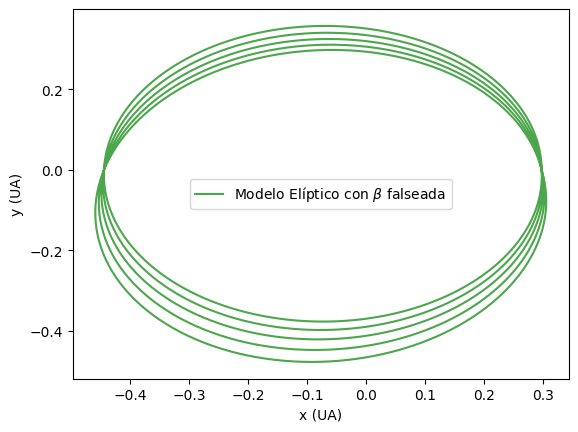

In [ ]:
# Pero vamos a usar la beta falsa, a ver qué ocurre
phi_falso = np.linspace(0, 10*np.pi, 1000)
u_einstein_falso = ####
r_einstein_falso = ####
x_einstein_falso = r_einstein_falso * np.cos(phi_falso)
y_einstein_falso = r_einstein_falso * np.sin(phi_falso)

# Graficar modelo teórico de Einstein

plt.plot(x_einstein_falso, y_einstein_falso, 'g', alpha=0.7, label=f'Modelo Elíptico con $\\beta$ falseada')
plt.xlabel('x (UA)')
plt.ylabel('y (UA)')
plt.legend(loc='upper right')
plt.show()

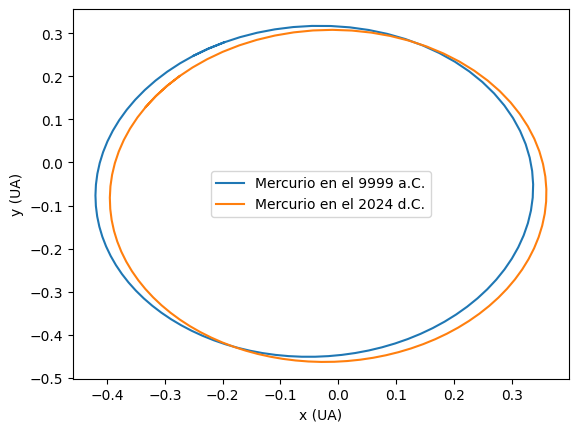

In [ ]:
# Órbita "Antigua" (9999 a.C.)
obj_old = Horizons(id='199', location='@sun',
                   epochs={'start': 'BC 9990-01-01', 'stop': 'BC 9990-04-01', 'step': '1d'})
vec_old = obj_old.vectors()

# Órbita "Moderna" (2024 d.C.)
obj_new = Horizons(id='199', location='@sun',
                   epochs={'start': '2024-01-01', 'stop': '2024-04-01', 'step': '1d'})
vec_new = obj_new.vectors()

# Al graficar ambas, verás un ligero desplazamiento en el ángulo del perihelio
plt.plot(vec_old['x'], vec_old['y'], label='Mercurio en el 9999 a.C.')
plt.plot(vec_new['x'], vec_new['y'], label='Mercurio en el 2024 d.C.')
plt.xlabel('x (UA)')
plt.ylabel('y (UA)')
plt.legend(loc='upper right')
plt.show()